# **BigQuery Connection**

In [3]:
from google.colab import auth
auth.authenticate_user()

In [4]:
from google.cloud import bigquery
import pandas as pd

In [5]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "lizbethpachecocapstonefinal"
client = bigquery.Client(project=PROJECT_ID)

In [6]:
query = """
SELECT *
FROM `lizbethpachecocapstonefinal.capstoneData.crashes`
"""
df = client.query(query).to_dataframe()

df.head()

,OBJECTID,CRASH_ID,CRASH_DATE,ROUTE,MILEPOINT,GCS_Lat,GCS_Long,MAIN_ROAD_,CITY,COUNTY_NAM,...,DOMESTIC_A,OVERTURN_R,COMMERCIAL,TEENAGE_DR,OLDER_DRIV,NIGHT_DARK,SINGLE_VEH,DISTRACTED,DROWSY_DRI,ROADWAY_DE
0,1457,11090600,2018 Sep 05 08:49:00 PM,<NA>,NaN,NaN,NaN,SR 30,None,RICH,...,True,False,False,False,False,True,True,False,False,False
1,1463,11092600,2018 Sep 11 09:00:00 AM,<NA>,NaN,40.439245,-109.563565,SR-44,None,DAGGETT,...,False,False,False,False,True,False,True,False,False,False
2,1493,11102100,2018 Sep 06 02:27:00 PM,<NA>,NaN,40.624907,-112.303741,ABERDEEN LN,None,TOOELE,...,False,False,False,False,True,False,False,False,False,False
3,1632,11136100,2019 Jan 09 07:29:00 PM,<NA>,NaN,41.725759,-112.194318,I-15,None,BOX ELDER,...,False,False,False,False,False,True,False,False,False,False
4,1672,11147100,2019 Jan 12 07:40:00 PM,<NA>,NaN,40.706736,-111.478246,SR-40,None,SUMMIT,...,False,False,False,False,False,True,True,False,False,False


The **State of Utah Crash Data 2015-2019** dataset was uploaded into BigQuery and imported into Google Colab for an EDA and data preparation.

# **SQL Data Acquisition**

In [7]:
df.columns

Index(['OBJECTID', 'CRASH_ID', 'CRASH_DATE', 'ROUTE', 'MILEPOINT', 'GCS_Lat',
       'GCS_Long', 'MAIN_ROAD_', 'CITY', 'COUNTY_NAM', 'CRASH_SEVE',
       'WORK_ZONE_', 'PEDESTRIAN', 'BICYCLIST_', 'MOTORCYCLE', 'IMPROPER_R',
       'UNRESTRAIN', 'DUI', 'INTERSECTI', 'WILD_ANIMA', 'DOMESTIC_A',
       'OVERTURN_R', 'COMMERCIAL', 'TEENAGE_DR', 'OLDER_DRIV', 'NIGHT_DARK',
       'SINGLE_VEH', 'DISTRACTED', 'DROWSY_DRI', 'ROADWAY_DE'],
      dtype='object')

In [8]:
# Count of Total Crash Records
query1 = """
SELECT COUNT(*) AS totalCrashes
FROM `lizbethpachecocapstonefinal.capstoneData.crashes`
"""
df1 = client.query(query1).to_dataframe()
df1

,totalCrashes
0,263851


In [9]:
# Crashes by County
query2 = """
SELECT COUNTY_NAM,
        COUNT(*) as crashCount
FROM `lizbethpachecocapstonefinal.capstoneData.crashes`
GROUP BY COUNTY_NAM
ORDER BY crashCount DESC
"""

df2 = client.query(query2).to_dataframe()
df2.head()

,COUNTY_NAM,crashCount
0,SALT LAKE,115591
1,UTAH,41892
2,DAVIS,24295
3,WEBER,18286
4,WASHINGTON,11573


In [10]:
# Crashes by Year
query3 = """
SELECT
  EXTRACT(YEAR FROM PARSE_TIMESTAMP('%Y %b %d %I:%M:%S %p', CRASH_DATE)) AS year,
  COUNT(*) AS crashCount
FROM `lizbethpachecocapstonefinal.capstoneData.crashes`
GROUP BY year
ORDER BY year
"""
df3 = client.query(query3).to_dataframe()
df3

,year,crashCount
0,2015,57525
1,2016,62363
2,2017,62855
3,2018,63628
4,2019,17480


I tried running **SELECT EXTRACT(YEAR FROM CRASH_DATE) AS year**, but got an error. I asked ChatGPT to help me fix it. I'll probably will have to convert this data type for easier analysis.

In [11]:
# Crash Severity
query4 = """
SELECT CRASH_SEVE,
       COUNT(*) AS totalCrashes
FROM `lizbethpachecocapstonefinal.capstoneData.crashes`
GROUP BY CRASH_SEVE
ORDER BY totalCrashes DESC
"""

df4 = client.query(query4).to_dataframe()
df4

,CRASH_SEVE,totalCrashes
0,1,187081
1,2,45615
2,3,25107
3,4,5001
4,5,1047


Seeing the distribution of crash severity can help identify the most common outcome of a crash.

In [12]:
# Severe Crashes Only
query5 = """
SELECT
  COUNTY_NAM,
  COUNT(*) AS severeCrashCount
FROM `lizbethpachecocapstonefinal.capstoneData.crashes`
WHERE CRASH_SEVE >= 4
GROUP BY COUNTY_NAM
ORDER BY severeCrashCount DESC
"""

df5 = client.query(query5).to_dataframe()
df5.head()

,COUNTY_NAM,severeCrashCount
0,SALT LAKE,2039
1,UTAH,856
2,WEBER,459
3,DAVIS,421
4,WASHINGTON,322


Filtered the dataset to only show higher severity crashes to show which counties have the most serious crash outcomes.

# **DataFrame Creation**

In [13]:
# Row and Column Counts
print("Full Dataset Shape:", df.shape)

Full Dataset Shape: (263851, 30)


In [14]:
# Crash Dataset
query_full = """
SELECT *
FROM `lizbethpachecocapstonefinal.capstoneData.crashes`
"""

df = client.query(query_full).to_dataframe()
df.head(5)

,OBJECTID,CRASH_ID,CRASH_DATE,ROUTE,MILEPOINT,GCS_Lat,GCS_Long,MAIN_ROAD_,CITY,COUNTY_NAM,...,DOMESTIC_A,OVERTURN_R,COMMERCIAL,TEENAGE_DR,OLDER_DRIV,NIGHT_DARK,SINGLE_VEH,DISTRACTED,DROWSY_DRI,ROADWAY_DE
0,1457,11090600,2018 Sep 05 08:49:00 PM,<NA>,NaN,NaN,NaN,SR 30,None,RICH,...,True,False,False,False,False,True,True,False,False,False
1,1463,11092600,2018 Sep 11 09:00:00 AM,<NA>,NaN,40.439245,-109.563565,SR-44,None,DAGGETT,...,False,False,False,False,True,False,True,False,False,False
2,1493,11102100,2018 Sep 06 02:27:00 PM,<NA>,NaN,40.624907,-112.303741,ABERDEEN LN,None,TOOELE,...,False,False,False,False,True,False,False,False,False,False
3,1632,11136100,2019 Jan 09 07:29:00 PM,<NA>,NaN,41.725759,-112.194318,I-15,None,BOX ELDER,...,False,False,False,False,False,True,False,False,False,False
4,1672,11147100,2019 Jan 12 07:40:00 PM,<NA>,NaN,40.706736,-111.478246,SR-40,None,SUMMIT,...,False,False,False,False,False,True,True,False,False,False


In [15]:
# County Dataframe
df_county = client.query(query2).to_dataframe()
df_county.head(3)

,COUNTY_NAM,crashCount
0,SALT LAKE,115591
1,UTAH,41892
2,DAVIS,24295


In [16]:
# Severity Dataframe
df_severity = client.query(query4).to_dataframe()
df_severity.head(3)

,CRASH_SEVE,totalCrashes
0,1,187081
1,2,45615
2,3,25107


In [17]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263851 entries, 0 to 263850
Data columns (total 30 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   OBJECTID    263851 non-null  Int64  
 1   CRASH_ID    263851 non-null  Int64  
 2   CRASH_DATE  263851 non-null  object 
 3   ROUTE       240432 non-null  Int64  
 4   MILEPOINT   240461 non-null  float64
 5   GCS_Lat     253128 non-null  float64
 6   GCS_Long    253128 non-null  float64
 7   MAIN_ROAD_  263833 non-null  object 
 8   CITY        258620 non-null  object 
 9   COUNTY_NAM  263851 non-null  object 
 10  CRASH_SEVE  263851 non-null  Int64  
 11  WORK_ZONE_  261771 non-null  boolean
 12  PEDESTRIAN  263851 non-null  boolean
 13  BICYCLIST_  263851 non-null  boolean
 14  MOTORCYCLE  263851 non-null  boolean
 15  IMPROPER_R  263851 non-null  boolean
 16  UNRESTRAIN  263851 non-null  boolean
 17  DUI         263851 non-null  boolean
 18  INTERSECTI  263851 non-null  boolean
 19  WI

**Observations**

The main dataset contains 263,851 records with 30 columns.

It includes crash ID, data and time info, location, severity, and variables related to driver behaivors and crash conditions.

Most of the columns have complete data, but there are some fields like ROUTE,MILEPOINT, and CITY that will need to looked at during the next step.

CRASH_DATE is stored as an object and will have to be looked at as well.


# **Data Quality Assessment**

In [18]:
# Missing Values
missingValues = df.isnull().sum()
missingValues[missingValues > 0].sort_values(ascending=False)

,0
ROUTE,23419
MILEPOINT,23390
GCS_Lat,10723
GCS_Long,10723
CITY,5231
WORK_ZONE_,2080
MAIN_ROAD_,18


In [19]:
# Duplicate Records
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [20]:
# Unique Counties
df['COUNTY_NAM'].value_counts().sort_index()

,count
COUNTY_NAM,
BEAVER,955
BOX ELDER,5242
CACHE,9088
CARBON,1829
DAGGETT,137
DAVIS,24295
DUCHESNE,1613
EMERY,1189
GARFIELD,901


In [21]:
# Crash severity values
df['CRASH_SEVE'].value_counts().sort_index()

,count
CRASH_SEVE,
1,187081
2,45615
3,25107
4,5001
5,1047


The dataset has various columns with missing values, with  ROUTE and MILEPOINT being the highest in missing records.

There are no duplicates in the dataset.

Checked COUNTY_NAM to see if there was any inconsistent variables, but there are none.

There are missing values and date formatting issues that were previously mentioned that will need to be fixed during the data preparation step.

# **Data Preparation**

In [22]:
# Converting CRASH_DATE with the help of ChatGPT
df['CRASH_DATE'] = pd.to_datetime(
    df['CRASH_DATE'],
    format='%Y %b %d %I:%M:%S %p'
)

df['CRASH_DATE'].head()

,CRASH_DATE
0,2018-09-05 20:49:00
1,2018-09-11 09:00:00
2,2018-09-06 14:27:00
3,2019-01-09 19:29:00
4,2019-01-12 19:40:00


In [23]:
# Creating YEAR column
df['YEAR'] = df['CRASH_DATE'].dt.year

df[['CRASH_DATE', 'YEAR']].head()

,CRASH_DATE,YEAR
0,2018-09-05 20:49:00,2018
1,2018-09-11 09:00:00,2018
2,2018-09-06 14:27:00,2018
3,2019-01-09 19:29:00,2019
4,2019-01-12 19:40:00,2019


In [24]:
# Creating MONTH column
df['MONTH'] = df['CRASH_DATE'].dt.month_name()

df[['CRASH_DATE', 'MONTH']].head()

,CRASH_DATE,MONTH
0,2018-09-05 20:49:00,September
1,2018-09-11 09:00:00,September
2,2018-09-06 14:27:00,September
3,2019-01-09 19:29:00,January
4,2019-01-12 19:40:00,January


In [25]:
# Creating SEASON column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['SEASON'] = df['CRASH_DATE'].dt.month.apply(get_season)

df[['CRASH_DATE', 'SEASON']].head()

,CRASH_DATE,SEASON
0,2018-09-05 20:49:00,Fall
1,2018-09-11 09:00:00,Fall
2,2018-09-06 14:27:00,Fall
3,2019-01-09 19:29:00,Winter
4,2019-01-12 19:40:00,Winter


Since weather conditions can be a variable in a crash, a seasons column can help us identify if it is true.

In [26]:
# Filling in missing CITY values
df['CITY'] = df['CITY'].fillna('Unknown')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263851 entries, 0 to 263850
Data columns (total 33 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   OBJECTID    263851 non-null  Int64         
 1   CRASH_ID    263851 non-null  Int64         
 2   CRASH_DATE  263851 non-null  datetime64[ns]
 3   ROUTE       240432 non-null  Int64         
 4   MILEPOINT   240461 non-null  float64       
 5   GCS_Lat     253128 non-null  float64       
 6   GCS_Long    253128 non-null  float64       
 7   MAIN_ROAD_  263833 non-null  object        
 8   CITY        263851 non-null  object        
 9   COUNTY_NAM  263851 non-null  object        
 10  CRASH_SEVE  263851 non-null  Int64         
 11  WORK_ZONE_  261771 non-null  boolean       
 12  PEDESTRIAN  263851 non-null  boolean       
 13  BICYCLIST_  263851 non-null  boolean       
 14  MOTORCYCLE  263851 non-null  boolean       
 15  IMPROPER_R  263851 non-null  boolean       
 16  UN

**Summary**

Several transformations were performed to prepare the dataset for analysis.

The CRASH_DATE column was converted from a text field to a datetime format.

New YEAR and MONTH columns were created from the crash date to support trend analysis.

A SEASON column was created to group crashes into Winter, Spring, Summer, and Fall categories. This will help identify seasonal crash patterns.

Missing values in the CITY column were replaced with "Unknown" to preserve records while improving consistency.

The remaining missing values were retained because they represent unavailable location information rather than data entry errors. To prevent loss of substantial data, these missing values will be left alone.

# **Exploratory Data Analysis**

In [28]:
df['CRASH_SEVE'].value_counts()

,count
CRASH_SEVE,
1,187081
2,45615
3,25107
4,5001
5,1047


Most of the crashes fall into severity level 1, while more severe crashes are rare.

In [29]:
df['YEAR'].value_counts().sort_index()

,count
YEAR,
2015,57525
2016,62363
2017,62855
2018,63628
2019,17480


Crash counts increased from 2015 to 2018, but then saw a decline in 2019.

In [30]:
df['SEASON'].value_counts()

,count
SEASON,
Winter,77118
Fall,65731
Spring,61810
Summer,59192


Crash counts were the highest during winter months and lowest during the summer, this can suggest that seasonal weather conditions may influence crash rates.

In [31]:
df['COUNTY_NAM'].value_counts().head(10)

,count
COUNTY_NAM,
SALT LAKE,115591
UTAH,41892
DAVIS,24295
WEBER,18286
WASHINGTON,11573
CACHE,9088
BOX ELDER,5242
SUMMIT,5054
TOOELE,4984


Salt Lake County had the most crashes compared to the other counties, this can be due higher population and traffic.

In [32]:
df['DUI'].value_counts()

,count
DUI,
False,254715
True,9136


DUI-related crashes represent a small portion of the total accidents, but still a safety concern.

In [33]:
df['NIGHT_DARK'].value_counts()

,count
NIGHT_DARK,
False,196528
True,67323


A lot of crashes occured when there was daylight, but there is still a significant amount of crashes that occured during the night.  This can indicate that visibility may be another factor that causes crashes.

# **Visualizations**

In [40]:
import matplotlib.pyplot as plt

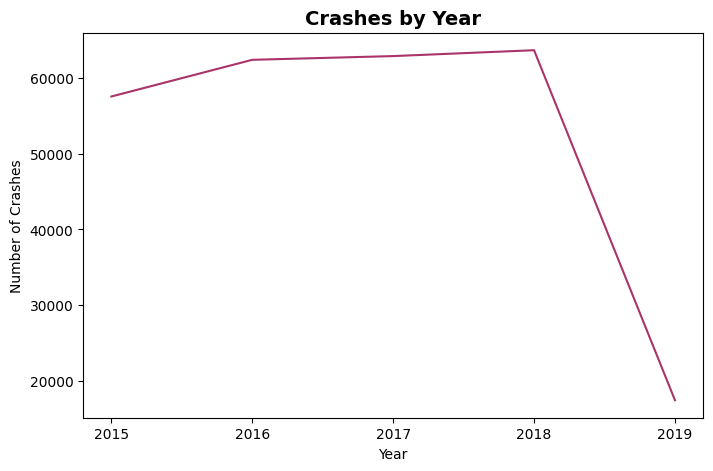

In [57]:
crashes_by_year = df['YEAR'].value_counts().sort_index()

crashes_by_year.plot(
    kind='line',
    figsize=(8,5),
    color='#AA336A',
    title='Crashes by Year'
)

plt.xlabel('Year')
plt.ylabel('Number of Crashes')
plt.xticks(crashes_by_year.index)
plt.show()

The line shows the increase of crash reports between 2015 to 2018 and then shows a decrease in reports in 2019.

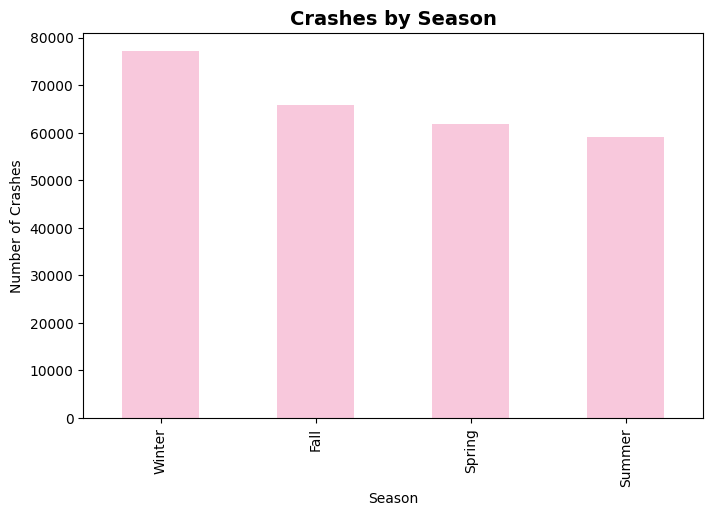

In [56]:
df['SEASON'].value_counts().plot(
    kind='bar',
    figsize=(8,5),
    color='#F8C8DC',
    title='Crashes by Season'
)

plt.xlabel('Season')
plt.ylabel('Number of Crashes')
plt.show()

Winter is the season with the most reported crashes, this can indicate that certain weather conditions can see more accidents.

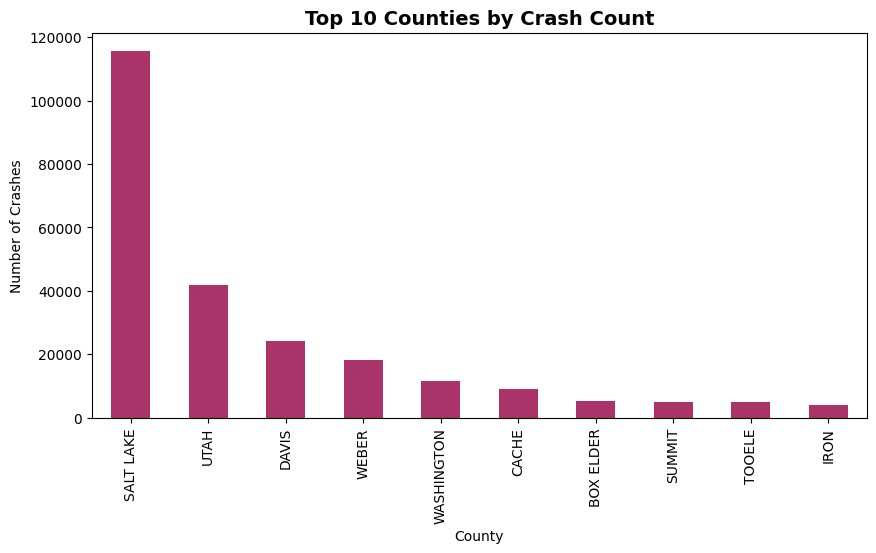

In [55]:
df['COUNTY_NAM'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5),
    color='#AA336A',
    title='Top 10 Counties by Crash Count'
)

plt.xlabel('County')
plt.ylabel('Number of Crashes')
plt.show()

Salt Lake County is the county with most crashes reported, this can be due larger population and heavier traffic.

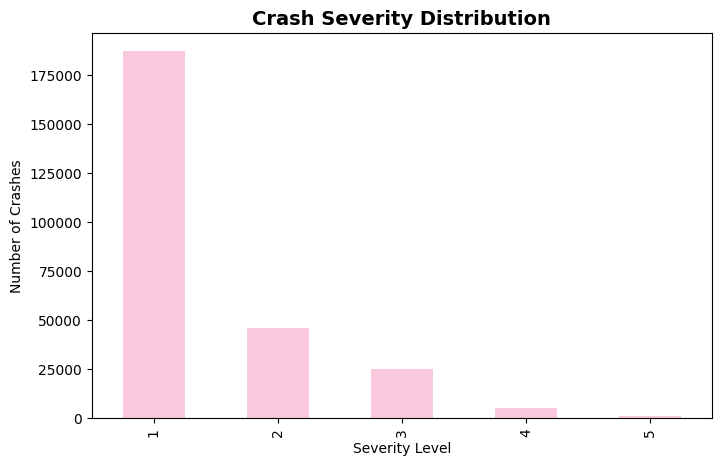

In [54]:
df['CRASH_SEVE'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(8,5),
    color='#F8C8DC',
    title='Crash Severity Distribution'
)

plt.xlabel('Severity Level')
plt.ylabel('Number of Crashes')
plt.show()

Most crashes fall under the level one of severity, but there are still crashes that fall into a higher severity levels.

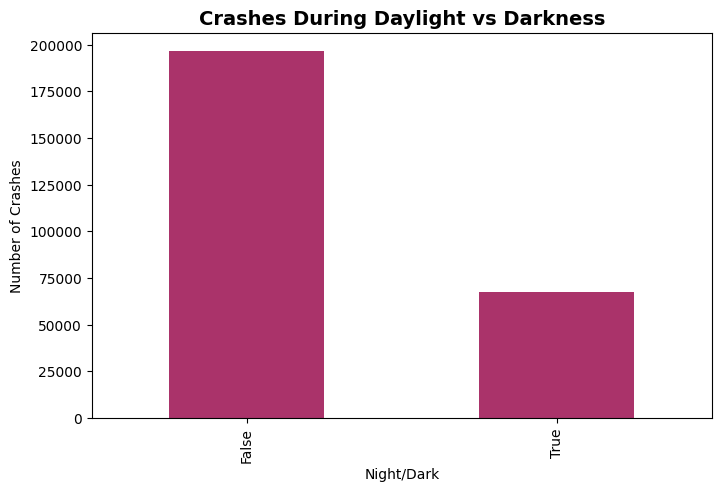

In [53]:
df['NIGHT_DARK'].value_counts().plot(
    kind='bar',
    figsize=(8,5),
    color='#AA336A',
    title='Crashes During Daylight vs Darkness'
)

plt.xlabel('Night/Dark')
plt.ylabel('Number of Crashes')
plt.show()

Crashes occured more during daylight, but there is still a significant amount that happened when it was dark, indicating visibility is another factor that can cause an accident.

In [58]:
# Sending new clean dataframe back to BigQuery
from pandas_gbq import to_gbq

to_gbq(
    df,
    destination_table = 'capstoneData.crashes_cleaned',
    project_id = 'lizbethpachecocapstonefinal',
    if_exists = 'replace'
)

100%|██████████| 1/1 [00:00<00:00, 7013.89it/s]
